In [1]:
import numpy as np
import matplotlib.pyplot as mp

# Nombre del archivo CSV que debe estar en la misma carpeta que este .ipynb
nombre_archivo_csv = "datos_sensores.csv"

# --- BLOQUE DE CARGA DE DATOS Y VERIFICACIÓN ---
try:
    # Cargar el archivo CSV
    datos = np.genfromtxt(
        nombre_archivo_csv,
        delimiter=",",
        skip_header=1,
        dtype=np.float64
    )

    # Verificación de éxito: debe ser un array 2D con 4 columnas
    if datos.ndim == 2 and datos.shape[1] == 4 and datos.shape[0] > 0:
        # Asignación de columnas
        ID = datos[:, 0]
        TEMPERATURA = datos[:, 1]
        HUMEDAD = datos[:, 2]
        ALERTA = datos[:, 3]

        print("=====================================================================")
        print(f"ÉXITO: Los datos de '{nombre_archivo_csv}' se han cargado correctamente.")
        print(f"Forma del array 'datos' (datos.shape): {datos.shape}")
        print(f"Tipo de datos (datos.dtype): {datos.dtype}")
        print("El array 'datos' y las columnas individuales (ID, TEMPERATURA, HUMEDAD, ALERTA) están listas para su uso.")
        print("=====================================================================")

        # Instrucción de renombrado
        print("\n¡ATENCIÓN! Proceso de carga completado con éxito.")
        print("Debe **renombrar** este archivo de plantilla como: `examen1_aadd.ipynb` (sustituyendo 'aadd' por sus iniciales).")

    else:
        print("ERROR: El archivo se encontró, pero el contenido del array cargado no tiene la forma esperada.")
        print("Debe tener 4 columnas y al menos 1 fila. Verifique el archivo CSV.")

except Exception as e:
    print("=====================================================================")
    print("ERROR FATAL: No se pudo cargar el archivo CSV.")
    print(f"Asegúrese de que el archivo '{nombre_archivo_csv}' se encuentra en la **misma carpeta** que este archivo de plantilla (.ipynb).")
    print(f"Error específico: {e}")
    print("=====================================================================")

ÉXITO: Los datos de 'datos_sensores.csv' se han cargado correctamente.
Forma del array 'datos' (datos.shape): (10000, 4)
Tipo de datos (datos.dtype): float64
El array 'datos' y las columnas individuales (ID, TEMPERATURA, HUMEDAD, ALERTA) están listas para su uso.

¡ATENCIÓN! Proceso de carga completado con éxito.
Debe **renombrar** este archivo de plantilla como: `examen1_aadd.ipynb` (sustituyendo 'aadd' por sus iniciales).


**Pregunta 1**

In [2]:
print("ID: ",ID[:5])
print("TEMPERATURA: ",TEMPERATURA[:5])
print("HUMEDAD: ",HUMEDAD[:5])
print("ALERTA: ",ALERTA[:5])

ID:  [1. 2. 3. 4. 5.]
TEMPERATURA:  [27.49 29.47 21.71 21.66 34.64]
HUMEDAD:  [63.04 57.7  66.23 69.41 93.94]
ALERTA:  [2. 2. 2. 3. 2.]


**Pregunta 2**

In [38]:
print("Media: ",np.mean(TEMPERATURA))
print("Mediana: ",np.median(TEMPERATURA))
print("Varianza: ",np.var(TEMPERATURA))
print("Desv. Estandar: ",np.std(TEMPERATURA))


Media:  24.966741
Mediana:  24.96
Varianza:  32.804066408919
Desv. Estandar:  5.727483427205966


La media es muy representativa porque tiene una desviación estandar bastante cercana, de tan solo 5,7º con respecto a esta.
La distribución es simétrica porque coincide con la mediana.

In [30]:
print("Percentil 25 (Q2):",np.percentile(TEMPERATURA,25))
print("Percentil 50 (Mediana):",np.percentile(TEMPERATURA,55))

Percentil 25: 20.05
Percentil 50: 25.93


**Pregunta 3**

In [5]:
humedad_clasificada = np.where(HUMEDAD < 40,1,np.where(HUMEDAD < 70,2,3))

#prueba = np.where(HUMEDAD < 40, 0,1) 
#print(np.any(prueba == 0)) # -> no hay umedad registrada por debajo de 40%
print("Condiciones\n")
print("Secas: ", np.sum([humedad_clasificada == 1]))
print("Confortables: ", np.sum([humedad_clasificada == 2]))
print("Húmedas:", np.sum([humedad_clasificada == 3]))

Condiciones

Secas:  0
Confortables:  5448
Húmedas: 4552


**Pregunta 4**

In [6]:
alerta_mas_100 = np.copy(ALERTA[100::10])
print("Nº Alertas a partir de 100:",len(alerta_mas_100))
print("Registos 5, 50, 500, 5000: ",ALERTA[[5, 50, 500, 5000]])
print("Alerta 3: ",np.sum([ALERTA == 3]))

Nº Alertas a partir de 100: 990
Registos 5, 50, 500, 5000:  [2. 3. 1. 1.]
Alerta 3:  3374


**Pregunta 5**

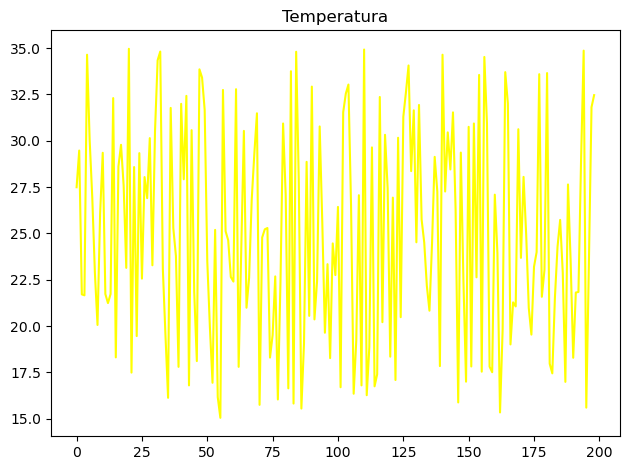

In [7]:
mp.plot(TEMPERATURA[:199], color="yellow") # falta
mp.title("Temperatura")
mp.legend
mp.tight_layout()
mp.show()

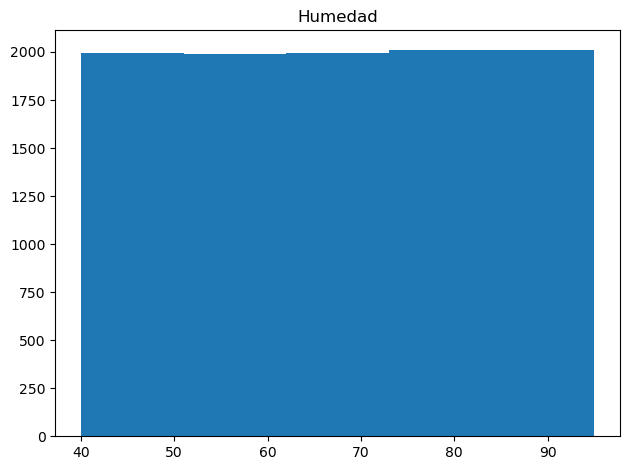

In [8]:
mp.hist(HUMEDAD,bins=5)
mp.title("Humedad")
mp.legend
mp.tight_layout()

In [9]:
print("Medidas\n")
print("Media: ",np.mean(HUMEDAD))
print("Mediana: ",np.median(HUMEDAD))
print("Desv. Estandar: ",np.std(HUMEDAD))
print("Percentil 25: ",np.percentile(HUMEDAD,25))
print("Percentil 75: ",np.percentile(HUMEDAD,75))
print("\nPrácticamente tres quintos del volumen de las barras del histograma. Casi corresponde el 50% de la muestra dentro del 50% del volumen del centro del histograma")

Medidas

Media:  67.544307
Mediana:  67.51
Desv. Estandar:  15.933112018678303
Percentil 25:  53.61
Percentil 75:  81.34

Prácticamente tres quintos del volumen de las barras del histograma. Casi corresponde el 50% de la muestra dentro del 50% del volumen del centro del histograma


Text(0.5, 1.0, 'Temperatura')

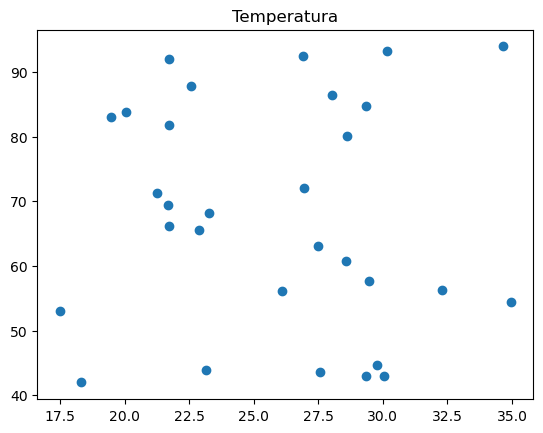

In [10]:
mp.scatter(TEMPERATURA[:30],HUMEDAD[:30])
mp.title("Temperatura")